In [17]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score, f1_score, precision_score, recall_score,precision_recall_curve, roc_curve
from xgboost import XGBClassifier, plot_importance
from imblearn.over_sampling import SMOTE

In [18]:
df = pd.read_csv("../Data/Classi_Data/flight_dep_classi_tree.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45251 entries, 0 to 45250
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MONTH                      45251 non-null  int64  
 1   DAY_OF_MONTH               45251 non-null  int64  
 2   DAY_OF_WEEK                45251 non-null  int64  
 3   CRS_DEP_TIME               45251 non-null  float64
 4   CRS_ELAPSED_TIME           45251 non-null  float64
 5   OP_UNIQUE_CARRIER          45251 non-null  int64  
 6   ORIGIN                     45251 non-null  int64  
 7   DEST                       45251 non-null  int64  
 8   DISTANCE                   45251 non-null  float64
 9   HourlyDewPointTemperature  45251 non-null  float64
 10  HourlyDryBulbTemperature   45251 non-null  float64
 11  HourlyRelativeHumidity     45251 non-null  float64
 12  HourlyVisibility           45251 non-null  float64
 13  HourlyWindSpeed            45251 non-null  flo

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,CRS_ELAPSED_TIME,OP_UNIQUE_CARRIER,ORIGIN,DEST,DISTANCE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed,DEP_DEL15
count,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000,45251.000000
mean,5.081081,15.932311,3.984199,13.870102,186.627765,4.200504,3.671742,44.542949,1205.290137,43.022055,59.705642,57.664516,9.813032,8.275154,0.218979
std,0.812057,8.731382,2.005295,5.251356,85.743290,3.868250,0.924941,25.794514,741.393100,6.686872,9.294924,18.485242,0.972448,3.818006,0.413559
min,4.000000,1.000000,1.000000,0.080000,49.000000,0.000000,0.000000,0.000000,93.000000,5.000000,30.000000,11.000000,0.000000,0.000000,0.000000
25%,4.000000,8.000000,2.000000,9.670000,128.000000,1.000000,4.000000,21.000000,679.000000,39.000000,53.000000,43.000000,10.000000,6.000000,0.000000
50%,5.000000,16.000000,4.000000,13.500000,167.000000,3.000000,4.000000,42.000000,1024.000000,43.000000,58.000000,59.000000,10.000000,8.000000,0.000000
75%,6.000000,23.000000,6.000000,17.980000,247.000000,9.000000,4.000000,67.000000,1721.000000,48.000000,65.000000,71.000000,10.000000,10.000000,0.000000
max,6.000000,31.000000,7.000000,23.980000,411.000000,11.000000,4.000000,85.000000,2724.000000,60.000000,102.000000,100.000000,10.000000,30.000000,1.000000


In [19]:
X = df.drop(columns=["DEP_DEL15"])
y = df["DEP_DEL15"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(y_train.value_counts(normalize=True))

Training set: (36200, 14), Test set: (9051, 14)
DEP_DEL15
0.0    0.781022
1.0    0.218978
Name: proportion, dtype: float64


In [21]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE:", y_train_res.value_counts(normalize=True))


After SMOTE: DEP_DEL15
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


In [22]:
#scale_pos = y_train.value_counts()[0] / y_train.value_counts()[1]
#print(f" scale_pos_weight = {scale_pos:.2f}")

xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False,
    #scale_pos_weight=scale_pos
)

In [23]:
param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5, 10]
}

In [24]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

start = time.time()
grid.fit(X_train_res, y_train_res)
end = time.time()

print(f" Time: {end - start:.2f} s")
print(" Best Parameters:", grid.best_params_)
print(f" Best CV ROC-AUC: {grid.best_score_:.4f}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits


c:\Users\ADMIN\Intro_DS\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:09:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Time: 76.74 s
 Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 400, 'subsample': 0.8}
 Best CV ROC-AUC: 0.9130


In [25]:
best_xgb = grid.best_estimator_

y_pred_default = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred_default)
prec = precision_score(y_test, y_pred_default)
rec = recall_score(y_test, y_pred_default)
f1 = f1_score(y_test, y_pred_default)
roc = roc_auc_score(y_test, y_prob)

print("\n XGBoost Classifier – Default Threshold (0.5)")
print(f"Accuracy : {acc:.4f}")
print(f"Precision (delay=1) : {prec:.4f}")
print(f"Recall (delay=1)    : {rec:.4f}")
print(f"F1-score (delay=1)  : {f1:.4f}")
print(f"ROC-AUC             : {roc:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_default, digits=4))


 XGBoost Classifier – Default Threshold (0.5)
Accuracy : 0.7731
Precision (delay=1) : 0.4588
Recall (delay=1)    : 0.2023
F1-score (delay=1)  : 0.2808
ROC-AUC             : 0.6853

 Classification Report:
              precision    recall  f1-score   support

         0.0     0.8067    0.9331    0.8653      7069
         1.0     0.4588    0.2023    0.2808      1982

    accuracy                         0.7731      9051
   macro avg     0.6327    0.5677    0.5730      9051
weighted avg     0.7305    0.7731    0.7373      9051




 Threshold Optimization
Best Threshold: 0.142
Precision: 0.299
Recall:    0.781
F1-score:  0.433


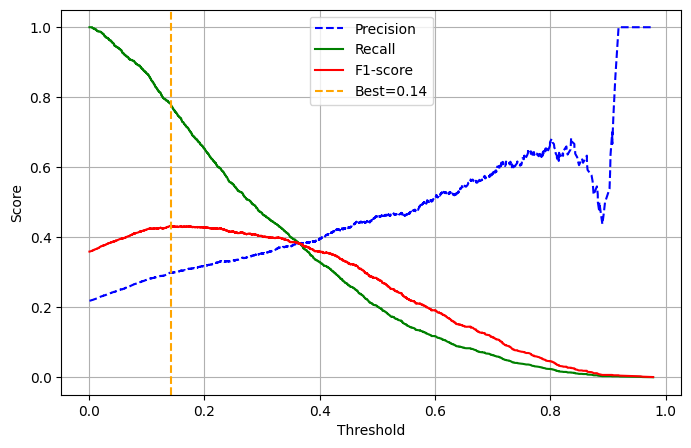

In [26]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print("\n Threshold Optimization")
print(f"Best Threshold: {best_thresh:.3f}")
print(f"Precision: {precisions[best_idx]:.3f}")
print(f"Recall:    {recalls[best_idx]:.3f}")
print(f"F1-score:  {f1_scores[best_idx]:.3f}")

# Precision–Recall vs Threshold (XGBoost)
plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1-score')
plt.axvline(x=best_thresh, color='orange', linestyle='--', label=f'Best={best_thresh:.2f}')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
y_pred_best = (y_prob >= best_thresh).astype(int)

acc2 = accuracy_score(y_test, y_pred_best)
prec2 = precision_score(y_test, y_pred_best)
rec2 = recall_score(y_test, y_pred_best)
f12 = f1_score(y_test, y_pred_best)
roc2 = roc_auc_score(y_test, y_prob)

print("\n Re-evaluate with Optimized Threshold")
print(f"Accuracy : {acc2:.4f}")
print(f"Precision (delay=1) : {prec2:.4f}")
print(f"Recall (delay=1)    : {rec2:.4f}")
print(f"F1-score (delay=1)  : {f12:.4f}")
print(f"ROC-AUC             : {roc2:.4f}")

print("\n Updated Classification Report:")
print(classification_report(y_test, y_pred_best, digits=4))


 Re-evaluate with Optimized Threshold
Accuracy : 0.5518
Precision (delay=1) : 0.2994
Recall (delay=1)    : 0.7810
F1-score (delay=1)  : 0.4328
ROC-AUC             : 0.6853

 Updated Classification Report:
              precision    recall  f1-score   support

         0.0     0.8881    0.4875    0.6295      7069
         1.0     0.2994    0.7810    0.4328      1982

    accuracy                         0.5518      9051
   macro avg     0.5938    0.6343    0.5311      9051
weighted avg     0.7592    0.5518    0.5864      9051



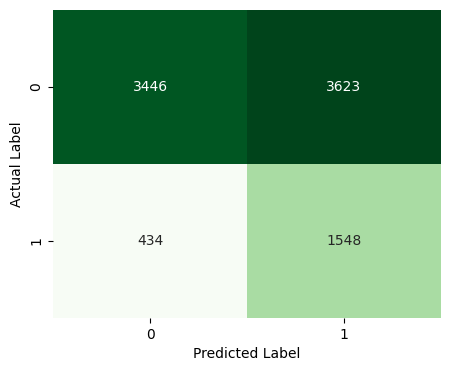

In [33]:
# Confusion Matrix – XGBoost (Optimized Threshold)
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

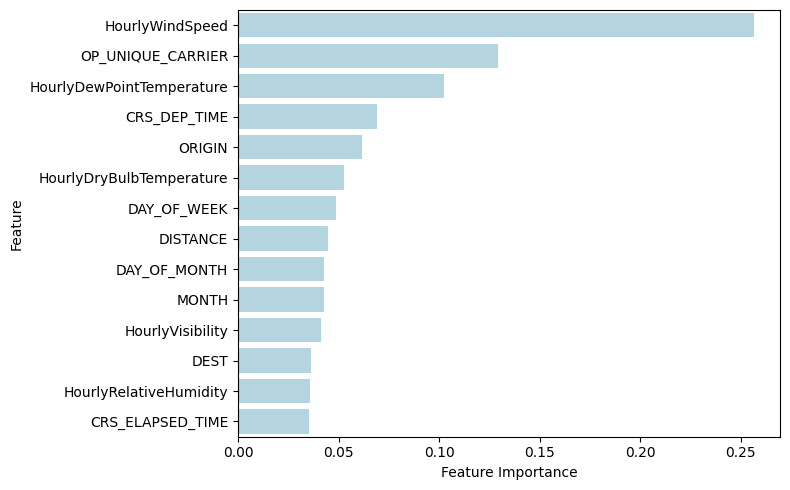

In [29]:
# Top 15 Important Features (XGBoost)
importances = best_xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp[:15], y=feat_imp.index[:15], color='lightblue')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

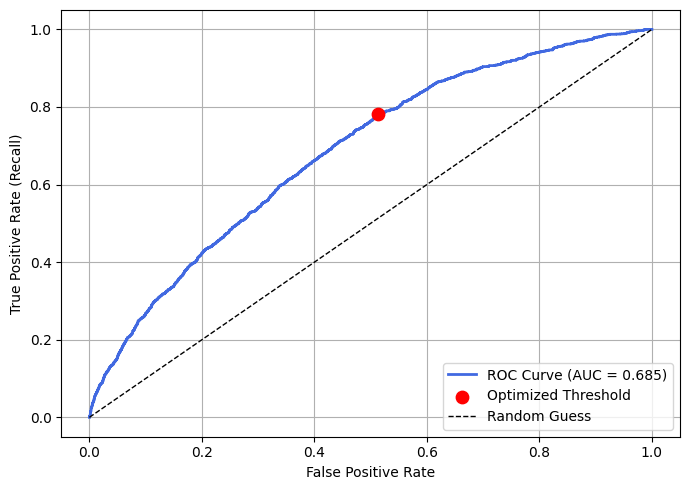

In [35]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

best_idx_roc = np.argmin(np.abs(thresholds_roc - best_thresh))

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="royalblue", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.scatter(
    fpr[best_idx_roc],
    tpr[best_idx_roc],
    color="red",
    s=80,
    label=f"Optimized Threshold",
    zorder=5
)
plt.plot([0,1],[0,1],'k--',lw=1,label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
#import joblib
#joblib.dump(best_xgb, r"D:\Project DS Final\Classi_Models\xgboost.pkl")